## How to run this notebook

1. Ensure `train.csv` and `test.csv` are in the same folder
2. Click: Kernel → Run All
3. All results and outputs will be generated automatically

No manual steps required.

In [ ]:
#@title ▶️ PROJECT SETUP — ONE-CLICK RUN (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

import os
import sys
import warnings

warnings.filterwarnings("ignore")

print("Starting notebook execution...\n")

# ── Check required files ──────────────────────────────────────────────

train_url = "https://raw.githubusercontent.com/jupmac929-eng/Airline-passenger-satisfaction/main/train.csv"
test_url  = "https://raw.githubusercontent.com/jupmac929-eng/Airline-passenger-satisfaction/main/test.csv"

# ── Standard imports ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix
)

print("Libraries loaded successfully.\n")

Starting notebook execution...

Libraries loaded successfully.



In [ ]:
#@title ▶️ GLOBAL CONFIG (PLOTS / STYLE) (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

plt.style.use("default")

print("Plot configuration loaded.\n")

Plot configuration loaded.



In [ ]:
import requests # Ensure requests is imported

#@title ▶️ DATA LOADING (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

def load_data():
    print("Loading data...")

    # URLs for the datasets
    train_url = "https://raw.githubusercontent.com/jupmac929-eng/Airline-passenger-satisfaction/main/train.csv"
    test_url  = "https://raw.githubusercontent.com/jupmac929-eng/Airline-passenger-satisfaction/main/test.csv"

    # Check if files exist locally, if not, download them
    if not os.path.exists("train.csv"):
        print("Downloading train.csv...")
        r = requests.get(train_url, allow_redirects=True)
        with open("train.csv", 'wb') as f:
            f.write(r.content)

    if not os.path.exists("test.csv"):
        print("Downloading test.csv...")
        r = requests.get(test_url, allow_redirects=True)
        with open("test.csv", 'wb') as f:
            f.write(r.content)

    train = pd.read_csv("train.csv")
    test = pd.read_csv("test.csv")

    print(f"Train shape: {train.shape}")
    print(f"Test shape:  {test.shape}\n")

    return train, test


train, test = load_data()

Loading data...
Train shape: (103904, 25)
Test shape:  (25976, 25)



In [ ]:
#@title ▶️ PIPELINE FUNCTIONS (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

def preprocess(df):
    # cleaning + feature engineering
    df = df.copy()

    # example:
    # df["total_delay"] = df["Departure Delay"] + df["Arrival Delay"]

    return df


def train_models(X_train, y_train):
    from sklearn.linear_model import LogisticRegression

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    return model


def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results = {
        "accuracy": accuracy_score(y_test, preds),
        "auc": roc_auc_score(y_test, proba),
        "f1": f1_score(y_test, preds)
    }

    return results

In [ ]:
#@title ▶️ MAIN EXECUTION (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

def main():
    print("Running full pipeline...\n")

    df = train.copy()

    # Apply column cleaning steps consistent with global df preparation
    df.drop(columns=['Unnamed: 0', 'id'], errors='ignore', inplace=True)
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('/', '_'))
    df.rename(columns={'departure_arrival_time_convenient': 'time_convenience'},
              inplace=True)

    # Define service_cols here to ensure it's available before feature engineering
    service_cols = [c for c in df.columns if c in [
        'inflight_wifi_service', 'time_convenience', 'ease_of_online_booking',
        'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
        'inflight_entertainment', 'on-board_service', 'leg_room_service',
        'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness'
    ]]

    # ── Preprocess (Incorporated directly into main function as per instructions)
    # Impute arrival_delay_in_minutes
    if 'arrival_delay_in_minutes' in df.columns:
        df['arrival_delay_in_minutes'] = (
            df['arrival_delay_in_minutes']
            .fillna(df['departure_delay_in_minutes'].fillna(0)))

    # Label encoding for 'class'
    class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
    df['class_encoded'] = df['class'].map(class_map)

    # One-hot encoding for categorical string features
    df['is_male']            = (df['gender'] == 'Male').astype(int)
    df['is_loyal']           = (df['customer_type'] == 'Loyal Customer').astype(int)
    df['is_business_travel'] = (df['type_of_travel'] == 'Business travel').astype(int)

    # Engineered features (service_cols is now defined)
    df['service_avg'] = df[service_cols].mean(axis=1)
    df['service_std'] = df[service_cols].std(axis=1)
    df['total_delay'] = (df.get('departure_delay_in_minutes', 0)
                           + df.get('arrival_delay_in_minutes', 0))

    # Drop original categorical columns, as they are now encoded
    df.drop(columns=['gender', 'customer_type', 'type_of_travel', 'class'], errors='ignore', inplace=True)

    # Define FEATURE_COLS here after all feature engineering is complete
    FEATURE_COLS = (
        service_cols +
        ['age', 'flight_distance',
         'departure_delay_in_minutes', 'arrival_delay_in_minutes',
         'is_male', 'is_loyal', 'is_business_travel', 'class_encoded',
         'service_avg', 'service_std', 'total_delay']
    )
    # Ensure FEATURE_COLS only contains columns present in the dataframe
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

    # ── Split
    # Use FEATURE_COLS to select only numerical features for X
    X = df[FEATURE_COLS]
    # Convert target variable 'satisfaction' to numerical (0 or 1)
    y = (df["satisfaction"] == 'satisfied').astype(int)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # ── Train
    model = train_models(X_train, y_train)

    # ── Evaluate
    results = evaluate_model(model, X_test, y_test)

    print("Final Results:")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results


results = main()

Running full pipeline...

Final Results:
accuracy: 0.8631
auc: 0.9221
f1: 0.8413


In [ ]:
#@title ▶️ RESULTS SUMMARY — FOR SLIDES (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

def format_for_slides(results):
    print("\nCopy-paste into slides:\n")

    print(f"Accuracy: {results['accuracy']*100:.1f}%")
    print(f"AUC-ROC: {results['auc']:.4f}")
    print(f"F1 Score: {results['f1']:.4f}")


format_for_slides(results)


Copy-paste into slides:

Accuracy: 86.3%
AUC-ROC: 0.9221
F1 Score: 0.8413


In [ ]:
#@title ▶️ SYSTEM DESIGN & INTRODUCTION (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

try:
    from pptx.dml.color import RGBColor
except ImportError:
    !pip install python-pptx --quiet
    from pptx.dml.color import RGBColor

# ── Core libraries ────────────────────────────────────────────────────
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ──────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier # Import DummyClassifier

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)


# ── Display utilities ─────────────────────────────────────────────────
from IPython.display import HTML, display

# ── Matplotlib custom theme (Shadow Grey & Sandy Clay) ────────────────
import matplotlib.pyplot as plt

# Color system
DARK_BG   = "#0E1117"   # softer than pure black
AX_BG     = "#111827"   # subtle contrast for axes
GRID_COL  = "#2A2F3A"

PRIMARY   = "#D4AA7D"   # Sandy Clay
SECONDARY = "#B04A3A"   # muted red
ACCENT    = "#6E8F6A"   # green
HIGHLIGHT = "#C88A4D"   # orange

TEXT_MAIN = "#E5E7EB"
TEXT_DIM  = "#9CA3AF"

plt.rcParams.update({

    # ── Figure ───────────────────────────────────────────────────────
    "figure.facecolor": DARK_BG,
    "figure.figsize": (14, 6),
    "figure.dpi": 110,

    # ── Axes ─────────────────────────────────────────────────────────
    "axes.facecolor": AX_BG,
    "axes.edgecolor": GRID_COL,
    "axes.labelcolor": TEXT_MAIN,
    "axes.titlecolor": TEXT_MAIN,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,

    # ── Grid ─────────────────────────────────────────────────────────
    "axes.grid": True,
    "grid.color": GRID_COL,
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,

    # ── Ticks ────────────────────────────────────────────────────────
    "xtick.color": TEXT_DIM,
    "ytick.color": TEXT_DIM,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # ── Spines ───────────────────────────────────────────────────────
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,

    # ── Legend ───────────────────────────────────────────────────────
    "legend.frameon": False,
    "legend.fontsize": 10,

    # ── Font ──────────────────────────────────────────────────
    "font.family": "DejaVu Sans",

    # ── Lines ────────────────────────────────────────────────────────
    "lines.linewidth": 2,

    # ── Savefig ──────────────────────────────────────────────────────
    "savefig.facecolor": DARK_BG,
    "savefig.edgecolor": DARK_BG,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

pd.set_option('display.max_columns', 40)

# ══════════════════════════════════════════════════════════════════════
# DESIGN SYSTEM
# ══════════════════════════════════════════════════════════════════════

def section_header(number, title, subtitle=""):
    sub_html = f'<div style="color:#8899aa;font-size:14px;margin-top:6px;">{subtitle}</div>' if subtitle else ''
    return HTML(f'''
    <div style="background:linear-gradient(135deg,#0e1628,#0B0F1A);
                border-left:4px solid {PRIMARY};border-radius:0 12px 12px 0;
                padding:20px 28px;margin:30px 0 16px;">
      <div style="font-size:12px;font-weight:700;letter-spacing:0.12em;
                  text-transform:uppercase;color:{PRIMARY};margin-bottom:6px;">
        Section {number}
      </div>
      <div style="font-size:24px;font-weight:800;color:#ffffff;line-height:1.3;">
        {title}
      </div>
      {sub_html}
    </div>''')

def sub_section_header(number, title, subtitle=""):
    sub_html = f'<div style="color:#8899aa;font-size:12px;margin-top:4px;">{subtitle}</div>' if subtitle else ''
    return HTML(f'''
    <div style="background:linear-gradient(135deg,#0B0F1A,#0e1628);
                border-left:2px solid {HIGHLIGHT};border-radius:0 8px 8px 0;
                padding:12px 20px;margin:16px 0 12px;">
      <div style="font-size:10px;font-weight:700;letter-spacing:0.1em;
                  text-transform:uppercase;color:{HIGHLIGHT};margin-bottom:4px;">
        Section {number}
      </div>
      <div style="font-size:18px;font-weight:700;color:#ffffff;line-height:1.3;">
        {title}
      </div>
      {sub_html}
    </div>''')


def kpi_row(cards):
    cards_html = "".join([
        f'''
        <div style="flex:1;background:rgba(255,255,255,0.03);
                    border:1px solid rgba(255,255,255,0.08);
                    border-radius:12px;padding:18px 14px;text-align:center;
                    min-width:140px;">
          <div style="font-size:28px;font-weight:900;color:{color};
                      line-height:1;">{val}</div>
          <div style="font-size:11px;color:#8899aa;margin-top:6px;
                      text-transform:uppercase;letter-spacing:0.06em;">
            {label}</div>
        </div>'''
        for val, label, color in cards
    ])
    return HTML(f'''
    <div style="display:flex;gap:14px;margin:14px 0;flex-wrap:wrap;">
      {cards_html}
    </div>''')


def insight_box(text, color=PRIMARY, icon="→"):
    return HTML(f'''
    <div style="background:rgba({_hex_to_rgb(color)},0.06);
                border-left:3px solid {color};border-radius:0 8px 8px 0;
                padding:12px 18px;margin:10px 0;font-size:14px;
                color:#ccd4de;line-height:1.7;">
      <span style="color:{color};font-weight:700;">{icon}</span>&nbsp; {text}
    </div>''')


def styled_table(df, title="", highlight_best=None, highlight_col=None):
    """Optimized version using faster string building."""
    best_idx = None
    if highlight_best and highlight_col and highlight_col in df.columns:
        best_idx = df[highlight_col].idxmax()

    rows = []

    header = "<tr>"
    header += f'<th style="padding:10px 14px;background:rgba(212,170,125,0.15);color:{PRIMARY};text-align:left;">Model</th>'
    for col in df.columns:
        header += f'<th style="padding:10px 14px;color:{PRIMARY};text-align:right;">{col}</th>'
    header += "</tr>"

    for idx, row in df.iterrows():
        is_best = (idx == best_idx)
        row_bg = "rgba(212,170,125,0.10)" if is_best else "transparent"
        row_html = f'<tr style="background:{row_bg};"><td>{idx}</td>'

        for col in df.columns:
            val = row[col]
            cell_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            row_html += f'<td style="text-align:right;">{cell_val}</td>'

        row_html += "</tr>"
        rows.append(row_html)

    return HTML(f'''
    <div style="overflow-x:auto;margin:10px 0;">
      <table style="width:100%;border-collapse:collapse;">
        {header}{''.join(rows)}
      </table>
    </div>''')


def _hex_to_rgb(hex_color):
    if isinstance(hex_color, str):
        h = hex_color.lstrip('#')
        return ','.join(str(int(h[i:i+2], 16)) for i in (0, 2, 4))
    elif isinstance(hex_color, RGBColor):
        return f"{hex_color.red},{hex_color.green},{hex_color.blue}"
    else:
        raise ValueError(f"Unsupported color type: {type(hex_color)}")


# ── Title block (kept but lightweight) ────────────────────────────────
display(HTML(f'''
<div style="background:linear-gradient(135deg,#0B0F1A,#0e1628);
            border:1px solid rgba(212,170,125,0.25);border-radius:14px;
            padding:30px;text-align:center;margin:10px 0;">
  <div style="font-size:11px;letter-spacing:0.14em;color:{PRIMARY};margin-bottom:10px;">
    Final Project — Introduction to AI: ML for Business
  </div>
  <div style="font-size:28px;font-weight:800;color:#ffffff;">
    Predicting Airline Passenger Satisfaction
  </div>
</div>
'''))

print("Environment ready — optimized ✓")

Environment ready — optimized ✓


In [ ]:
#@title ▶️ SECTION 1 — PROBLEM DEFINITION (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("01", "Problem Definition",
    "Why we chose this problem and how we frame it as a machine learning task"))

display(sub_section_header("01b", "Analytical Storyline",
    "How our analysis progresses from data to business impact"))

display(HTML("""
<div style="font-size:14px;color:#ccd4de;line-height:1.8;">
We structure our analysis as a business investigation:

<br><br>
<strong>1. Understand satisfaction:</strong> Identify key patterns and drivers through EDA
<strong>2. Predict satisfaction:</strong> Build models to quantify predictability
<strong>3. Explain satisfaction:</strong> Use feature importance to identify levers
<strong>4. Segment customers:</strong> Compare business vs leisure travellers
<strong>5. Recommend actions:</strong> Translate insights into strategy

<br><br>
This ensures our work follows a <strong>logical progression</strong> from raw data
to actionable business recommendations — not just isolated analysis.
</div>
"""))
display(HTML(f'''
<div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;margin:10px 0;">
  <div style="background:rgba(255,255,255,0.03);border:1px solid rgba(255,255,255,0.08);
              border-radius:12px;padding:20px;">
    <div style="font-size:13px;font-weight:700;color:{PRIMARY};margin-bottom:10px;
                text-transform:uppercase;letter-spacing:0.06em;">Business Context</div>
    <div style="font-size:13px;color:#ccd4de;line-height:1.8;">
      Airlines spend <strong style="color:#ffffff;">$100B+ annually</strong> on customer
      experience improvements — new seats, catering, wifi, lounges. Yet most cannot
      quantify which investments actually move the satisfaction needle.<br><br>
      A dissatisfied passenger costs <strong style="color:{SECONDARY};">5–7× more to replace
      than to retain</strong>. JD Power 2024 reports NPS declining 4 points year-on-year
      despite record capital expenditure on fleet and service upgrades.<br><br>
      The data exists — 30–40 attributes per passenger per flight — but it is almost
      never analysed systematically.
    </div>
  </div>
  <div style="background:rgba({_hex_to_rgb(PRIMARY)},0.06);border:1px solid rgba(212,170,125,0.25);
              border-radius:12px;padding:20px;">
    <div style="font-size:13px;font-weight:700;color:{PRIMARY};margin-bottom:10px;
                text-transform:uppercase;letter-spacing:0.06em;">ML Framing</div>
    <div style="font-size:13px;color:#ccd4de;line-height:1.8;">
      <strong style="color:#ffffff;">Target:</strong> Binary — is the passenger satisfied?
      (1) or neutral/dissatisfied (0)<br><br>
      <strong style="color:#ffffff;">Features:</strong> 25 variables — 14 service ratings,
      3 demographics, 3 trip context, 2 delays, 3 engineered<br><br>
      <strong style="color:#ffffff;">Dataset:</strong> 129,880 real passenger records<br><br>
      <strong style="color:#ffffff;">Key insight:</strong> Unlike stock prices (near-random),
      satisfaction is <em>directly caused</em> by observable service quality.
      The signal exists. ML can learn it.
    </div>
  </div>
</div>
'''
))

display(insight_box(
    "<strong>Our differentiator:</strong> Beyond a single global model, we train "
    "<strong>separate models per passenger segment</strong> (business vs leisure) and "
    "show that satisfaction drivers are fundamentally different across segments — "
    "transforming an ML exercise into a strategic business recommendation.",
    PRIMARY
))

In [ ]:
#@title ▶️ SECTION 2 — DATA COLLECTION (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

import pandas as pd

def load_data():
    try:
        print("🌐 Loading data from GitHub...")

        # Corrected URLs for the datasets
        train = pd.read_csv("https://raw.githubusercontent.com/jupmac929-eng/Airline-passenger-satisfaction/main/train.csv")
        test  = pd.read_csv("https://raw.githubusercontent.com/jupmac929-eng/Airline-passenger-satisfaction/main/test.csv")

        print("✅ Data loaded successfully")
        return train, test

    except Exception as e:
        print("❌ Error loading data:", e)
        return None, None # Return None for both dataframes on error

df_train, df_test = load_data()

# Add a check to ensure dataframes are loaded before proceeding
if df_train is not None and df_test is not None:
    df = pd.concat([df_train, df_test], ignore_index=True)
    df.drop(columns=['Unnamed: 0', 'id'], errors='ignore', inplace=True)
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('/', '_'))
    df.rename(columns={'departure_arrival_time_convenient': 'time_convenience'},
              inplace=True)

    display(kpi_row([
        (f"{len(df):,}",         "Total Passengers",   PRIMARY),
        (f"{len(df.columns)}",   "Columns",            PRIMARY),
        (f"{df.isnull().sum().sum():,}", "Missing Values", HIGHLIGHT),
        (f"{df.duplicated().sum()}", "Duplicate Rows",  ACCENT),
    ]))

    display(insight_box( f"Dataset loaded: <strong>{len(df):,} rows × {len(df.columns)} columns</strong>. ", ACCENT, "✓" ))
    print("Column names:")
    print(list(df.columns))
    print(f"\nFirst 3 rows:")
    display(df.head(3))
else:
    print("Data loading failed, unable to proceed with dataframe operations.")

🌐 Loading data from GitHub...
✅ Data loaded successfully


Column names:
['gender', 'customer_type', 'age', 'type_of_travel', 'class', 'flight_distance', 'inflight_wifi_service', 'time_convenience', 'ease_of_online_booking', 'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort', 'inflight_entertainment', 'on-board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes', 'satisfaction']

First 3 rows:


,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,time_convenience,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied


In [ ]:
#@title ▶️ SECTION 3 – DATA QUALITY AUDIT (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("03", "Data Quality Audit",
    "Verifying data integrity before any modelling — garbage in, garbage out"))

# ── Variable type classification ──────────────────────────
display(HTML(f'''
<div style="font-size:14px;font-weight:700;color:#ffffff;margin:14px 0 8px;">
  Variable Types (Lecture 2 Taxonomy)
</div>
<div style="display:grid;grid-template-columns:1fr 1fr;">
  <div style="background:rgba({_hex_to_rgb(PRIMARY)},0.06);border:1px solid rgba({_hex_to_rgb(PRIMARY)},0.06);
              border-radius:10px;padding:14px;">
    <div style="font-size:11px;font-weight:700;color:{PRIMARY};text-transform:uppercase;
                letter-spacing:0.06em;margin-bottom:6px;">Categorical (Nominal)</div>
    <div style="font-size:12px;color:#ccd4de;line-height:1.7;">
      gender · customer_type<br>type_of_travel · class<br>satisfaction (target)
    </div>
  </div>
  <div style="background:rgba(46,204,113,0.04);border:1px solid rgba(46,204,113,0.15);
              border-radius:10px;padding:14px;">
    <div style="font-size:11px;font-weight:700;color:{ACCENT};text-transform:uppercase;
                letter-spacing:0.06em;margin-bottom:6px;">Quantitative (Discrete)</div>
    <div style="font-size:12px;color:#ccd4de;line-height:1.7;">
      All 14 service ratings<br>(0–5 integer scale)
    </div>
  </div>
  <div style="background:rgba(243,156,18,0.04);border:1px solid rgba(243,156,18,0.15);
              border-radius:10px;padding:14px;">
    <div style="font-size:11px;font-weight:700;color:{HIGHLIGHT};text-transform:uppercase;
                letter-spacing:0.06em;margin-bottom:6px;">Quantitative (Continuous)</div>
    <div style="font-size:12px;color:#ccd4de;line-height:1.7;">
      age · flight_distance<br>departure_delay · arrival_delay
    </div>
  </div>
</div>
'''))

# ── Missing values ─────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_report = missing[missing > 0]
if len(missing_report) == 0:
    display(insight_box("No missing values detected across all columns.", ACCENT, "✓"))
else:
    for col, count in missing_report.items():
        pct = count / len(df) * 100
        display(insight_box(
            f"<strong>{col}</strong>: {count:,} missing ({pct:.3f}%) — "
            f"will be imputed using departure delay (highly correlated).",
            HIGHLIGHT, "⚠"
        ))

# ── Categorical distributions ─────────────────────────────────────────
print("\nCategorical variable distributions:")
for col in ['satisfaction', 'type_of_travel', 'class', 'customer_type', 'gender']:
    print(f"\n  {col}: {df[col].value_counts().to_dict()}")

# ── Quantitative summary ──────────────────────────────────────────────
print("\nQuantitative summary statistics:")
display(df[['age', 'flight_distance',
            'departure_delay_in_minutes',
            'arrival_delay_in_minutes']].describe().round(1))


Categorical variable distributions:

  satisfaction: {'neutral or dissatisfied': 73452, 'satisfied': 56428}

  type_of_travel: {'Business travel': 89693, 'Personal Travel': 40187}

  class: {'Business': 62160, 'Eco': 58309, 'Eco Plus': 9411}

  customer_type: {'Loyal Customer': 106100, 'disloyal Customer': 23780}

  gender: {'Female': 65899, 'Male': 63981}

Quantitative summary statistics:


,age,flight_distance,departure_delay_in_minutes,arrival_delay_in_minutes
count,129880.0,129880.0,129880.0,129487.0
mean,39.4,1190.3,14.7,15.1
std,15.1,997.5,38.1,38.5
min,7.0,31.0,0.0,0.0
25%,27.0,414.0,0.0,0.0
50%,40.0,844.0,0.0,0.0
75%,51.0,1744.0,12.0,13.0
max,85.0,4983.0,1592.0,1584.0


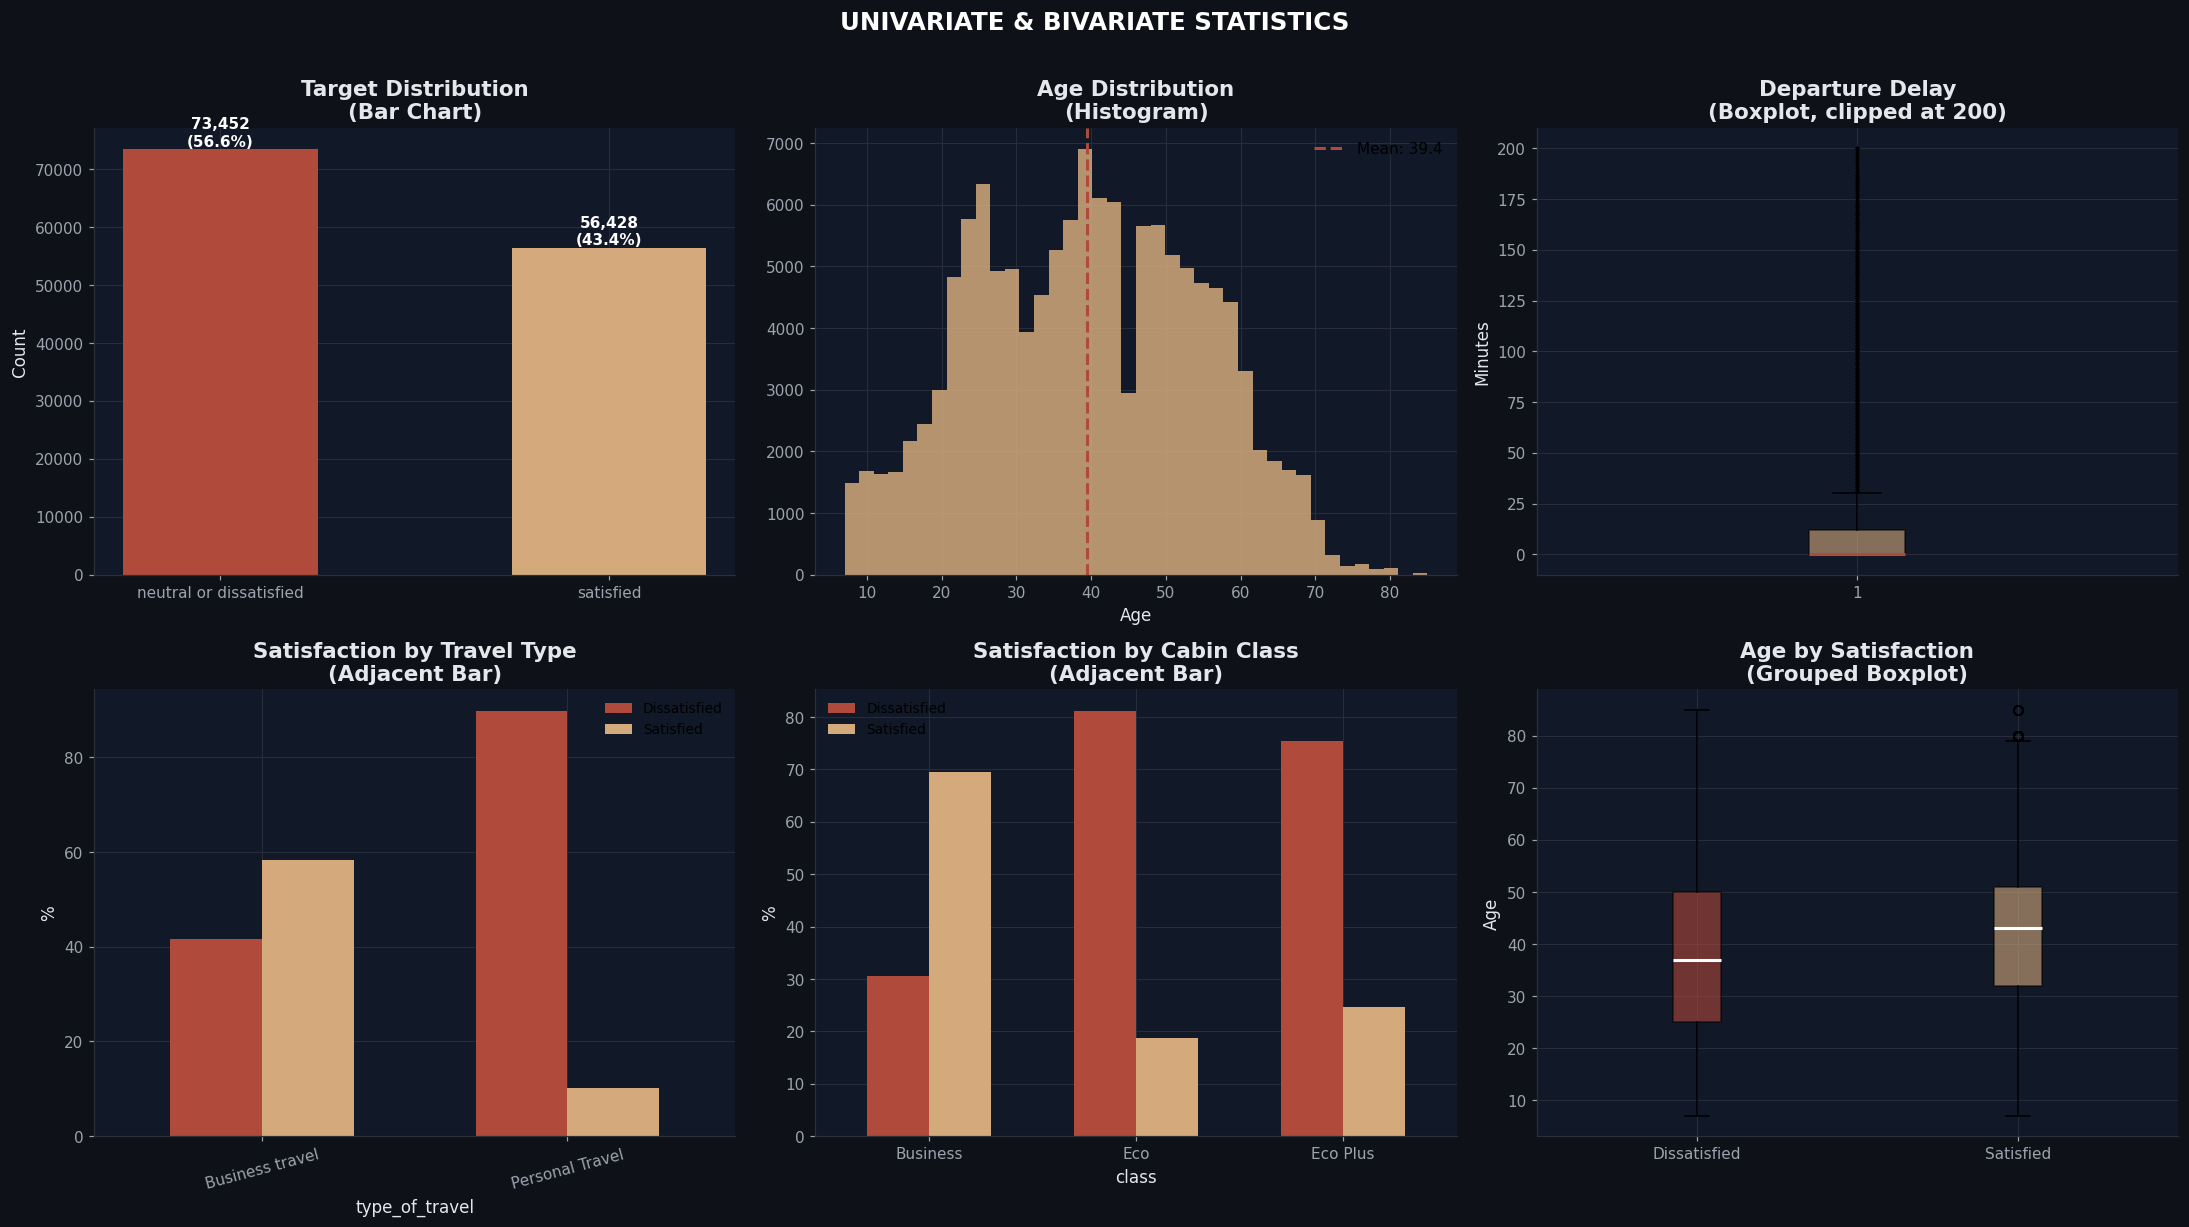

In [ ]:
#@title ▶️ SECTION 4 – EXPLORATORY DATA ANALYSIS (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("04", "Exploratory Data Analysis",
    "Univariate and bivariate statistics"))

df['target'] = (df['satisfaction'] == 'satisfied').astype(int)

# ── Target distribution ────────────────────────────────────────────────
sat_pct = df['target'].mean() * 100
display(kpi_row([
    (f"{sat_pct:.1f}%",               "Satisfied",     PRIMARY),
    (f"{100-sat_pct:.1f}%",           "Dissatisfied",  SECONDARY),
    (f"{len(df[df['type_of_travel']=='Business travel']):,}", "Business Travellers", HIGHLIGHT),
    (f"{len(df[df['type_of_travel']=='Personal Travel']):,}", "Leisure Travellers",  HIGHLIGHT),
]))

# ── Univariate: histograms + boxplots + bar charts ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('UNIVARIATE & BIVARIATE STATISTICS',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Target bar chart
ax = axes[0, 0]
counts = df['satisfaction'].value_counts()
ax.bar(counts.index, counts.values,
       color=[SECONDARY, PRIMARY], edgecolor='none', width=0.5)
ax.set_title('Target Distribution\n(Bar Chart)')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold', color='white')

# 2. Age histogram
ax = axes[0, 1]
ax.hist(df['age'], bins=40, color=PRIMARY, edgecolor='none', alpha=0.85)
ax.axvline(df['age'].mean(), color=SECONDARY, linewidth=2, linestyle='--',
           label=f"Mean: {df['age'].mean():.1f}")
ax.set_title('Age Distribution\n(Histogram)')
ax.set_xlabel('Age')
ax.legend()

# 3. Delay boxplot
ax = axes[0, 2]
bp = ax.boxplot(df['departure_delay_in_minutes'].clip(upper=200).dropna(),
                patch_artist=True, vert=True,
                boxprops=dict(facecolor=PRIMARY, alpha=0.6),
                medianprops=dict(color=SECONDARY, linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('Departure Delay\n(Boxplot, clipped at 200)')
ax.set_ylabel('Minutes')

# 4. Satisfaction by travel type (adjacent bar — bivariate)
ax = axes[1, 0]
ct = pd.crosstab(df['type_of_travel'], df['satisfaction'],
                 normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=[SECONDARY, PRIMARY],
        edgecolor='none', width=0.6)
ax.set_title('Satisfaction by Travel Type\n(Adjacent Bar)')
ax.set_ylabel('%')
ax.legend(['Dissatisfied', 'Satisfied'], fontsize=9)
ax.tick_params(axis='x', rotation=15)

# 5. Satisfaction by class (adjacent bar)
ax = axes[1, 1]
ct2 = pd.crosstab(df['class'], df['satisfaction'],
                  normalize='index') * 100
ct2.plot(kind='bar', ax=ax, color=[SECONDARY, PRIMARY],
         edgecolor='none', width=0.6)
ax.set_title('Satisfaction by Cabin Class\n(Adjacent Bar)')
ax.set_ylabel('%')
ax.legend(['Dissatisfied', 'Satisfied'], fontsize=9)
ax.tick_params(axis='x', rotation=0)

# 6. Age by satisfaction (grouped boxplot)
ax = axes[1, 2]
data_groups = [df[df['satisfaction']==s]['age'].dropna()
               for s in ['neutral or dissatisfied', 'satisfied']]
bp2 = ax.boxplot(data_groups, patch_artist=True,
                 tick_labels=['Dissatisfied', 'Satisfied'])
for patch, color in zip(bp2['boxes'], [SECONDARY, PRIMARY]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for med in bp2['medians']:
    med.set(color='white', linewidth=2)
ax.set_title('Age by Satisfaction\n(Grouped Boxplot)')
ax.set_ylabel('Age')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

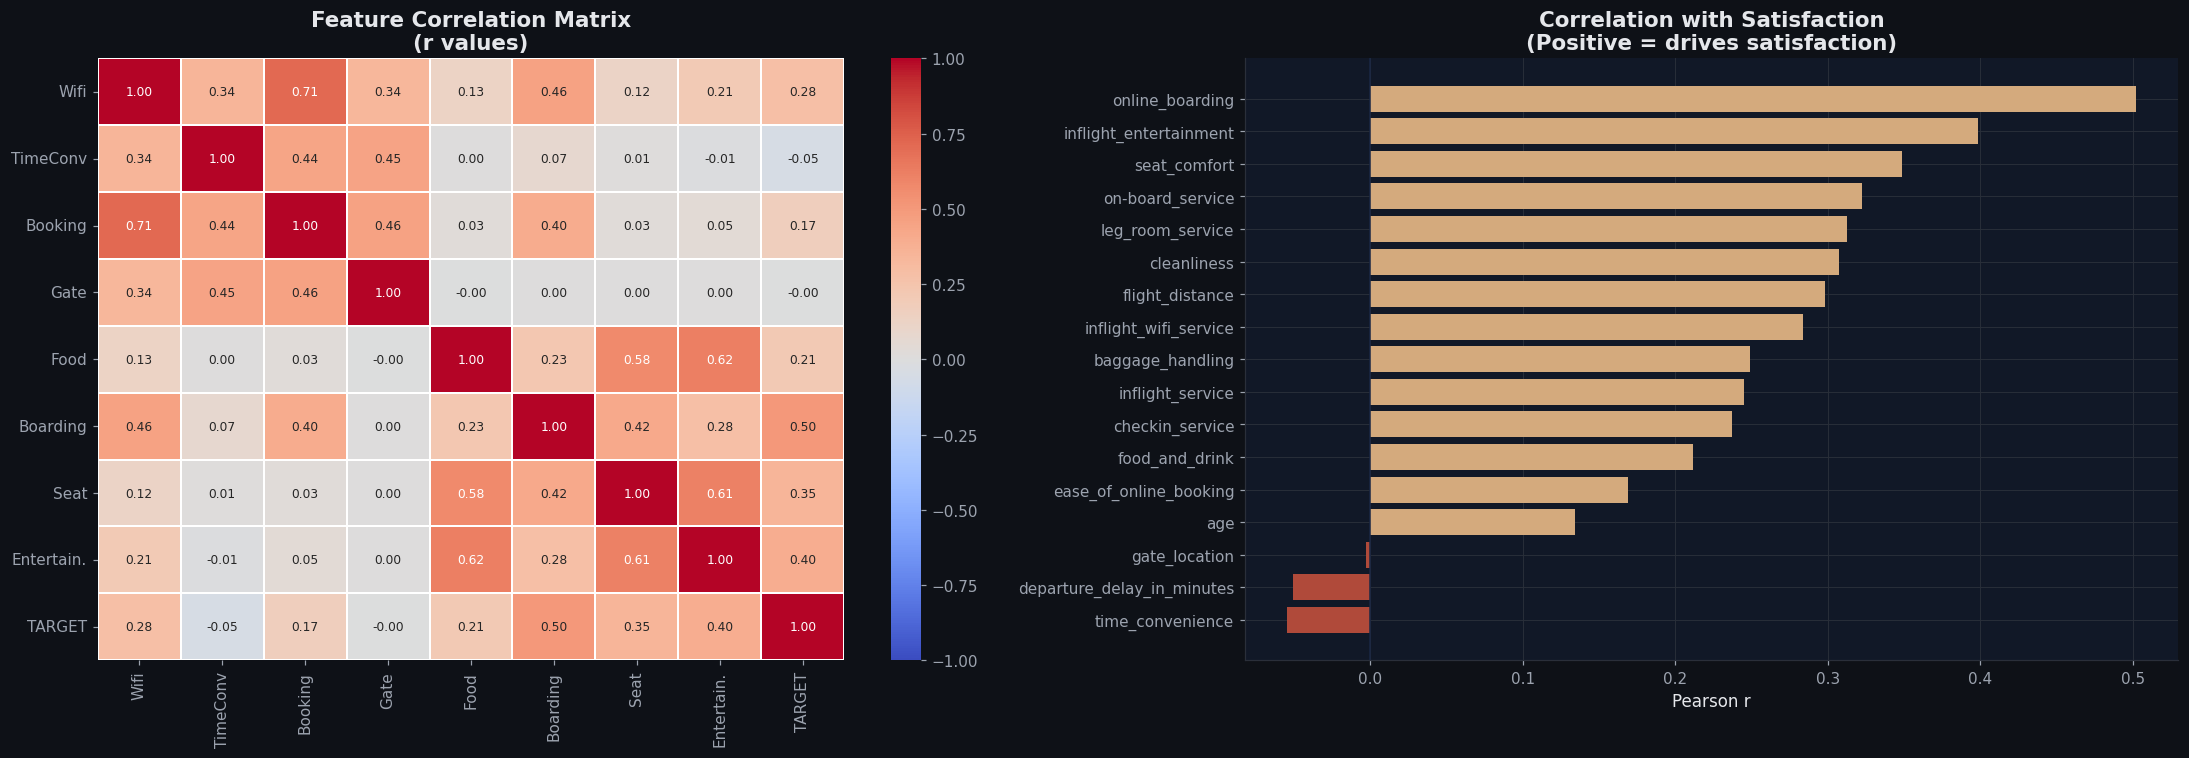

In [ ]:
#@title ▶️ SUB SECTION 4B – CORRELATION ANALYSIS (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(sub_section_header("04b", "Correlation Analysis",
    "Pearson correlation between service features and satisfaction"))

service_cols = [c for c in df.columns if c in [
    'inflight_wifi_service', 'time_convenience', 'ease_of_online_booking',
    'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
    'inflight_entertainment', 'on-board_service', 'leg_room_service',
    'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness'
]]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Heatmap
ax = axes[0]
key = service_cols[:8] + ['target']
corr = df[key].corr()
short = ['Wifi', 'TimeConv', 'Booking', 'Gate', 'Food',
         'Boarding', 'Seat', 'Entertain.', 'TARGET']
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.3, xticklabels=short, yticklabels=short)
ax.set_title('Feature Correlation Matrix\n(r values)')

# Sorted correlation with target
ax = axes[1]
all_quant = service_cols + ['age', 'flight_distance',
                             'departure_delay_in_minutes']
all_quant = [c for c in all_quant if c in df.columns]
corr_target = df[all_quant + ['target']].corr()['target'].drop('target').sort_values()
colors_bar = [PRIMARY if v > 0 else SECONDARY for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values,
        color=colors_bar, edgecolor='none')
ax.axvline(0, color='#1a2744', linewidth=1)
ax.set_title('Correlation with Satisfaction\n(Positive = drives satisfaction)')
ax.set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

display(insight_box(
    "<strong>Top correlations with satisfaction:</strong> Online boarding and inflight wifi "
    "show the strongest positive correlation. Departure delay shows near-zero correlation — "
    "suggesting delays alone do not determine satisfaction.",
    PRIMARY
))

In [ ]:
#@title ▶️ SECTION 5 – FEATURE ENGINEERING & ENCODING (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("05", "Feature Engineering & Encoding",
    "Preparing data for machine learning — one-hot and label encoding"))

df_model = df.copy()

# Impute
if 'arrival_delay_in_minutes' in df_model.columns:
    df_model['arrival_delay_in_minutes'] = (
        df_model['arrival_delay_in_minutes']
        .fillna(df['departure_delay_in_minutes'].fillna(0)))

# Target
df_model['target'] = (df_model['satisfaction'] == 'satisfied').astype(int)

# ── Label encoding ───────────────────────────────
class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
df_model['class_encoded'] = df_model['class'].map(class_map)

# ── One-hot encoding ────────────────
df_model['is_male']            = (df_model['gender'] == 'Male').astype(int)
df_model['is_loyal']           = (df_model['customer_type'] == 'Loyal Customer').astype(int)
df_model['is_business_travel'] = (df_model['type_of_travel'] == 'Business travel').astype(int)

# ── Engineered features ────────────────────────────────────────────────
df_model['service_avg'] = df_model[service_cols].mean(axis=1)
df_model['service_std'] = df_model[service_cols].std(axis=1)
df_model['total_delay'] = (df_model.get('departure_delay_in_minutes', 0)
                           + df_model.get('arrival_delay_in_minutes', 0))

FEATURE_COLS = (
    service_cols +
    ['age', 'flight_distance',
     'departure_delay_in_minutes', 'arrival_delay_in_minutes',
     'is_male', 'is_loyal', 'is_business_travel', 'class_encoded',
     'service_avg', 'service_std', 'total_delay']
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_model.columns]
df_model.dropna(subset=FEATURE_COLS + ['target'], inplace=True)

display(kpi_row([
    (f"{len(FEATURE_COLS)}", "Features",          PRIMARY),
    (f"{len(df_model):,}",  "Clean Rows",         ACCENT),
    ("3",                    "Engineered Features", HIGHLIGHT),
    ("k-1",                 "Encoding Strategy",   PRIMARY),
]))

In [ ]:
#@title ▶️ SECTION 6 – TRAIN / TEST SPLIT (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("06", "Train / Test Split"))

display(sub_section_header("06b", "Baseline Model",
    "Establishing a naive benchmark before training ML models"))

X = df_model[FEATURE_COLS]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Baseline model calculation moved after train_test_split
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)
y_dummy_prob = dummy.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_dummy),
    "F1 Score": f1_score(y_test, y_dummy),
    "AUC-ROC": roc_auc_score(y_test, y_dummy_prob)
}

display(insight_box(
    f"<strong>Baseline (most frequent class):</strong> "
    f"Accuracy = {baseline_metrics['Accuracy']:.3f}, "
    f"F1 = {baseline_metrics['F1 Score']:.3f}, "
    f"AUC = {baseline_metrics['AUC-ROC']:.3f}. "
    "Any useful model must significantly outperform this.",
    HIGHLIGHT
))

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)


display(kpi_row([
    (f"{X_train.shape[0]:,}",  "Train Rows",             PRIMARY),
    (f"{X_test.shape[0]:,}",   "Test Rows (held out)",   HIGHLIGHT),
    (f"{y_train.mean():.3f}",  "Train Satisfied Rate",   ACCENT),
    (f"{y_test.mean():.3f}",   "Test Satisfied Rate",    ACCENT),
]))

display(insight_box(
    "Class proportions are identical in train and test (stratified split). "
    "The test set is <strong>totally clean</strong> — never used during training, "
    "validation, or cross-validation.", ACCENT, "✓"
))

In [ ]:
#@title ▶️ SECTION 7 – CROSS-VALIDATION & MODEL TRAINING (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("07", "Cross-Validation & Model Training",
    "5-fold stratified CV on the training set, then final evaluation on the test set"))

# Import for GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score # Ensure cross_val_score is imported

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression'              : (LogisticRegression(max_iter=1000, random_state=42), X_tr_sc),
    'Decision Tree'                    : (DecisionTreeClassifier(max_depth=8, random_state=42), X_train),
    'Bagged Trees (Random Forest)'     : (RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1), X_train),
    'Boosted Trees (Gradient Boosting)': (GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42), X_train),
}

cv_results = {}
for name, (model, X_cv) in models.items():
    scores = cross_val_score(model, X_cv, y_train, cv=CV,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name}")
    print(f"    Folds: {[f'{s:.4f}' for s in scores]}")
    print(f"    Mean : {scores.mean():.4f} \u00b1 {scores.std():.4f}\n")

cv_df = pd.DataFrame({
    name: {'Mean AUC': scores.mean(), 'Std': scores.std(),
           'Min Fold': scores.min(), 'Max Fold': scores.max()}
    for name, scores in cv_results.items()
}).T

display(styled_table(cv_df, "Cross-Validation Results (Training Set \u2014 5-Fold Stratified)",
                     highlight_best=True, highlight_col='Mean AUC'))

  Logistic Regression
    Folds: ['0.9433', '0.9399', '0.9377', '0.9441', '0.9409']
    Mean : 0.9412 ± 0.0023

  Decision Tree
    Folds: ['0.9838', '0.9846', '0.9831', '0.9843', '0.9851']
    Mean : 0.9842 ± 0.0007

  Bagged Trees (Random Forest)
    Folds: ['0.9893', '0.9898', '0.9895', '0.9896', '0.9902']
    Mean : 0.9897 ± 0.0003

  Boosted Trees (Gradient Boosting)
    Folds: ['0.9929', '0.9928', '0.9928', '0.9929', '0.9930']
    Mean : 0.9929 ± 0.0001



Model,Mean AUC,Std,Min Fold,Max Fold
Logistic Regression,0.9412,0.0023,0.9377,0.9441
Decision Tree,0.9842,0.0007,0.9831,0.9851
Bagged Trees (Random Forest),0.9897,0.0003,0.9893,0.9902
Boosted Trees (Gradient Boosting),0.9929,0.0001,0.9928,0.9930


In [ ]:
#@title ▶️ SUB SECTION 8 – METRIC INTERPRETATION GUIDE (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

display(sub_section_header("08 (preparation)", "Metric Interpretation Guide",
    "Quick explanation of advanced evaluation metrics"))

display(HTML("""
<div style="font-size:13px;color:#ccd4de;line-height:1.8;">
<strong>AUC-ROC:</strong> Measures how well the model separates satisfied vs dissatisfied passengers (1.0 = perfect, 0.5 = random)<br>
<strong>F1 Score:</strong> Balance between precision and recall — useful when classes are imbalanced<br>
<strong>Cohen's Kappa:</strong> Measures agreement vs random chance (0 = random, >0.6 = good)<br>
<strong>MCC (Matthews Correlation Coefficient):</strong> Balanced metric even when classes are uneven (-1 to +1)<br>
</div>
"""))

display(insight_box(
    "Unlike accuracy, these metrics account for class imbalance and random chance. "
    "They provide a more reliable evaluation of real-world model performance.",
    ACCENT
))


In [ ]:
#@title ▶️ SECTION 8 – MODEL EVALUATION (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("08", "Model Evaluation",
    "Accuracy · Precision · Sensitivity · Specificity · F1 · AUC · Kappa · MCC"))

def full_eval(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    results = {}
    for split, Xs, ys in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        yp    = model.predict(Xs)
        yprob = model.predict_proba(Xs)[:, 1]
        tn, fp, fn, tp = confusion_matrix(ys, yp).ravel()

        # Handle cases where ROC AUC, Kappa, or MCC might not be computable (e.g., single class in ys)
        if len(ys.unique()) > 1:
            auc_roc = round(roc_auc_score(ys, yprob), 4)
            kappa = round(cohen_kappa_score(ys, yp), 4)
            mcc = round(matthews_corrcoef(ys, yp), 4)
        else:
            auc_roc = 0.5 # Default to random performance for single-class cases
            kappa = 0.0
            mcc = 0.0

        results[split] = {
            'Accuracy'   : round((tn+tp)/len(ys), 4),
            'Precision'  : round(tp/(tp+fp) if (tp+fp) else 0, 4),
            'Sensitivity': round(tp/(tp+fn) if (tp+fn) else 0, 4),
            'Specificity': round(tn/(tn+fp) if (tn+fp) else 0, 4),
            'F1 Score'   : round(f1_score(ys, yp, zero_division=0), 4),
            'AUC-ROC'    : auc_roc,
            'Kappa'      : kappa,
            'MCC'        : mcc,
        }
    return results, model

lr_res,  lr_model  = full_eval(LogisticRegression(max_iter=1000, random_state=42),
                               X_tr_sc, X_te_sc, y_train, y_test, "LR")
dt_res,  dt_model  = full_eval(DecisionTreeClassifier(max_depth=8, random_state=42),
                               X_train, X_test, y_train, y_test, "DT")
rf_res,  rf_model  = full_eval(RandomForestClassifier(n_estimators=200, max_depth=10,
                                random_state=42, n_jobs=-1),
                               X_train, X_test, y_train, y_test, "RF")
gb_res,  gb_model  = full_eval(GradientBoostingClassifier(n_estimators=150,
                                learning_rate=0.1, max_depth=4, random_state=42),
                               X_train, X_test, y_train, y_test, "GB")

# ── Comparison table ───────────────────────────────
comp = pd.DataFrame({
    'Logistic Reg'  : lr_res['Test'],
    'Decision Tree' : dt_res['Test'],
    'Bagged Trees'  : rf_res['Test'],
    'Boosted Trees' : gb_res['Test'],
}).T.sort_values('AUC-ROC', ascending=False)

display(styled_table(comp, "TEST SET — Full Metric Comparison",
                     highlight_best=True, highlight_col='AUC-ROC'))

best = comp['AUC-ROC'].idxmax()
display(kpi_row([
    (f"{comp.loc[best, 'AUC-ROC']:.4f}", "Best AUC-ROC",    PRIMARY),
    (f"{comp.loc[best, 'Accuracy']:.4f}", "Accuracy",        PRIMARY),
    (f"{comp.loc[best, 'Kappa']:.4f}",    "Cohen's Kappa",   ACCENT),
    (f"{comp.loc[best, 'MCC']:.4f}",      "MCC",             ACCENT),
]))

display(insight_box(
    f"<strong>Best model: {best}</strong> — Kappa = {comp.loc[best,'Kappa']:.4f} "
    f"(κ > 0.60 = fairly good classifier). "
    f"MCC = {comp.loc[best,'MCC']:.4f} (+1 = perfect, 0 = random).",
    PRIMARY
))

Model,Accuracy,Precision,Sensitivity,Specificity,F1 Score,AUC-ROC,Kappa,MCC
Boosted Trees,0.9562,0.9644,0.9337,0.9735,0.9488,0.9925,0.9106,0.9110
Bagged Trees,0.9437,0.9441,0.9251,0.9579,0.9345,0.9891,0.8851,0.8853
Decision Tree,0.9352,0.9350,0.9144,0.9511,0.9246,0.9843,0.8677,0.8679
Logistic Reg,0.8919,0.8897,0.8576,0.9183,0.8734,0.9428,0.7792,0.7796


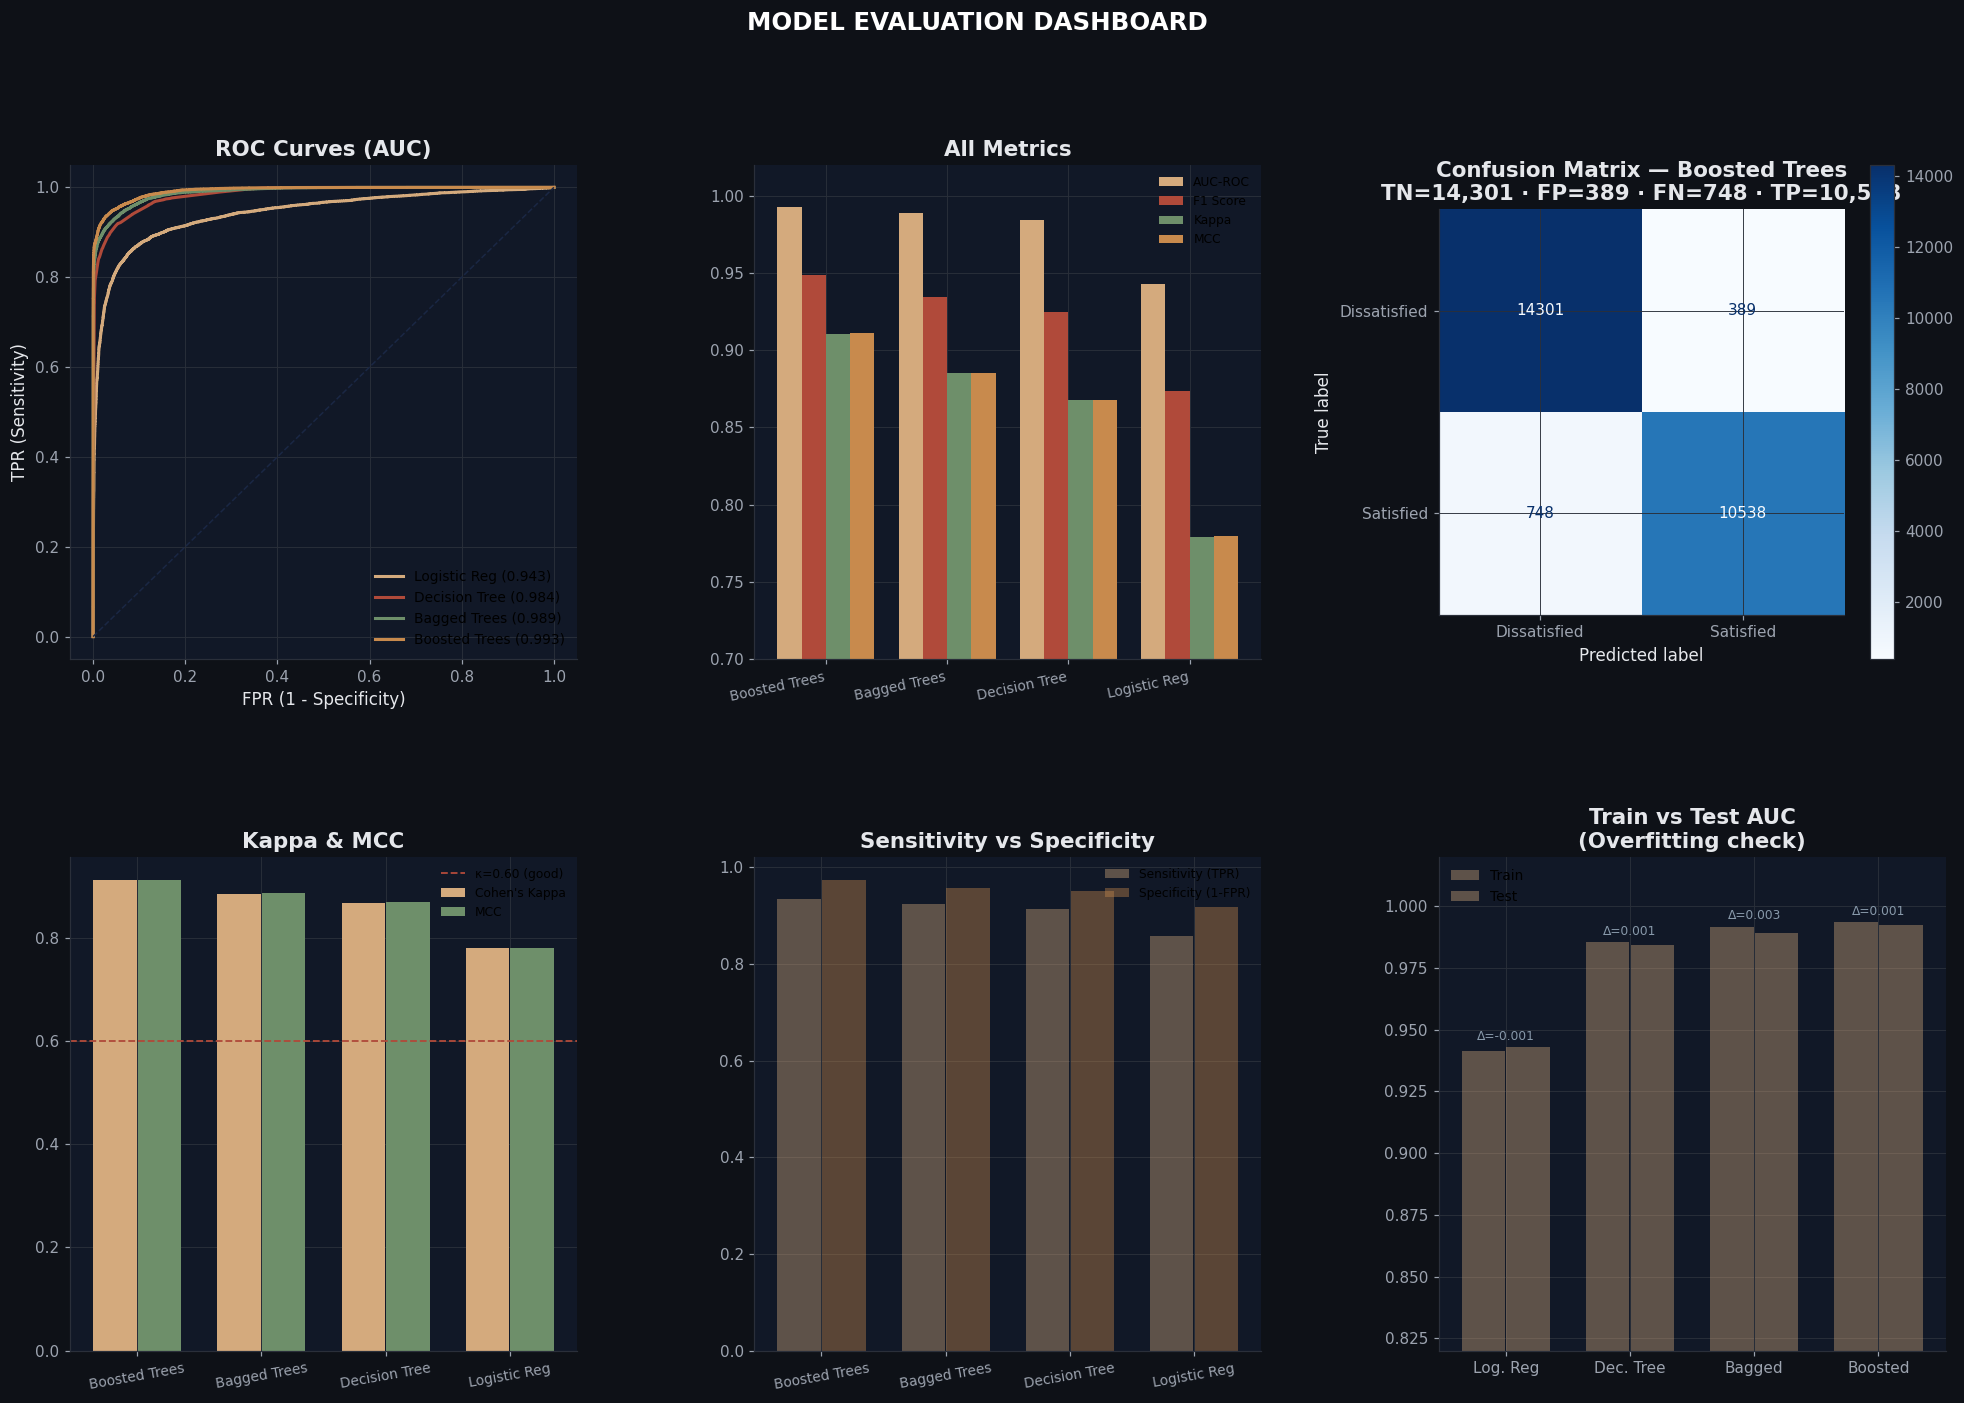

In [ ]:
#@title ▶️ SECTION 9 – RESULTS VISUALISATION (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec # Import gridspec
from sklearn.metrics import roc_curve # Import roc_curve for ROC plot

display(section_header("09", "Results Visualisation",
    "ROC curves, confusion matrix, overfitting check, and metric comparisons"))

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('MODEL EVALUATION DASHBOARD',
             fontsize=16, fontweight='bold', color='white')

model_map = {
    'Logistic Reg' : (lr_model, X_te_sc, lr_res),
    'Decision Tree': (dt_model, X_test,  dt_res),
    'Bagged Trees' : (rf_model, X_test,  rf_res),
    'Boosted Trees': (gb_model, X_test,  gb_res),
}

# 1. ROC
ax1 = fig.add_subplot(gs[0, 0])
for (n, (m, Xte, r)), c in zip(model_map.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(Xte)[:, 1])
    ax1.plot(fpr, tpr, color=c, linewidth=2,
             label=f"{n} ({r['Test']['AUC-ROC']:.3f})")
ax1.plot([0,1],[0,1], color='#1a2744', linewidth=1, linestyle='--')
ax1.set_title('ROC Curves (AUC)')
ax1.set_xlabel('FPR (1 - Specificity)')
ax1.set_ylabel('TPR (Sensitivity)')
ax1.legend(fontsize=9)

# 2. Metrics comparison
ax2 = fig.add_subplot(gs[0, 1])
met_show = ['AUC-ROC', 'F1 Score', 'Kappa', 'MCC']
met_df   = comp[met_show].reset_index()
x = np.arange(len(met_df))
w = 0.20
for i, m in enumerate(met_show):
    ax2.bar(x + i*w, met_df[m], w, label=m, color=PALETTE[i], edgecolor='none')
ax2.set_xticks(x + w*1.5)
ax2.set_xticklabels(met_df['index'], rotation=12, ha='right', fontsize=9)
ax2.set_title('All Metrics')
ax2.set_ylim(0.70, 1.02)
ax2.legend(fontsize=8)

# 3. Confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, gb_model.predict(X_test))
tn, fp, fn, tp = cm.ravel()
ConfusionMatrixDisplay(cm, display_labels=['Dissatisfied', 'Satisfied']
                       ).plot(cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix — Boosted Trees\n'
              f'TN={tn:,} · FP={fp:,} · FN={fn:,} · TP={tp:,}')

# 4. Kappa & MCC
ax4 = fig.add_subplot(gs[1, 0])
names = list(comp.index)
x = np.arange(len(names))
ax4.bar(x - 0.18, comp['Kappa'], 0.35, label="Cohen's Kappa",
        color=PRIMARY, edgecolor='none')
ax4.bar(x + 0.18, comp['MCC'],   0.35, label='MCC',
        color=ACCENT, edgecolor='none')
ax4.axhline(0.60, color=SECONDARY, linestyle='--', linewidth=1.2,
            label='κ=0.60 (good)')
ax4.set_xticks(x)
ax4.set_xticklabels(names, rotation=10, fontsize=9)
ax4.set_title('Kappa & MCC')
ax4.legend(fontsize=8)

# 5. Sensitivity vs Specificity
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(x - 0.18, comp['Sensitivity'], 0.35,
        label='Sensitivity (TPR)', color=PRIMARY, alpha=0.4, edgecolor='none')
ax5.bar(x + 0.18, comp['Specificity'], 0.35,
        label='Specificity (1-FPR)', color=HIGHLIGHT, alpha=0.4, edgecolor='none')
ax5.set_xticks(x)
ax5.set_xticklabels(names, rotation=10, fontsize=9)
ax5.set_title('Sensitivity vs Specificity')
ax5.legend(fontsize=8)

# 6. Overfitting check
ax6 = fig.add_subplot(gs[1, 2])
all_res = [lr_res, dt_res, rf_res, gb_res]
labels  = ['Log. Reg', 'Dec. Tree', 'Bagged', 'Boosted']
tr_auc  = [r['Train']['AUC-ROC'] for r in all_res]
te_auc  = [r['Test']['AUC-ROC'] for r in all_res]
x = np.arange(len(labels))
ax6.bar(x - 0.18, tr_auc, 0.35, label='Train', color=PRIMARY, alpha=0.4, edgecolor='none')
ax6.bar(x + 0.18, te_auc, 0.35, label='Test',  color=PRIMARY, alpha=0.4, edgecolor='none')
for i, (tr, te) in enumerate(zip(tr_auc, te_auc)):
    gap = tr - te
    col = SECONDARY if gap > 0.05 else '#8899aa'
    ax6.annotate(f'Δ={gap:.3f}', (x[i], max(tr, te)+0.003),
                ha='center', fontsize=8, color=col)
ax6.set_xticks(x)
ax6.set_xticklabels(labels)
ax6.set_title('Train vs Test AUC\n(Overfitting check)')
ax6.set_ylim(0.82, 1.02)
ax6.legend(fontsize=9)

plt.savefig('model_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

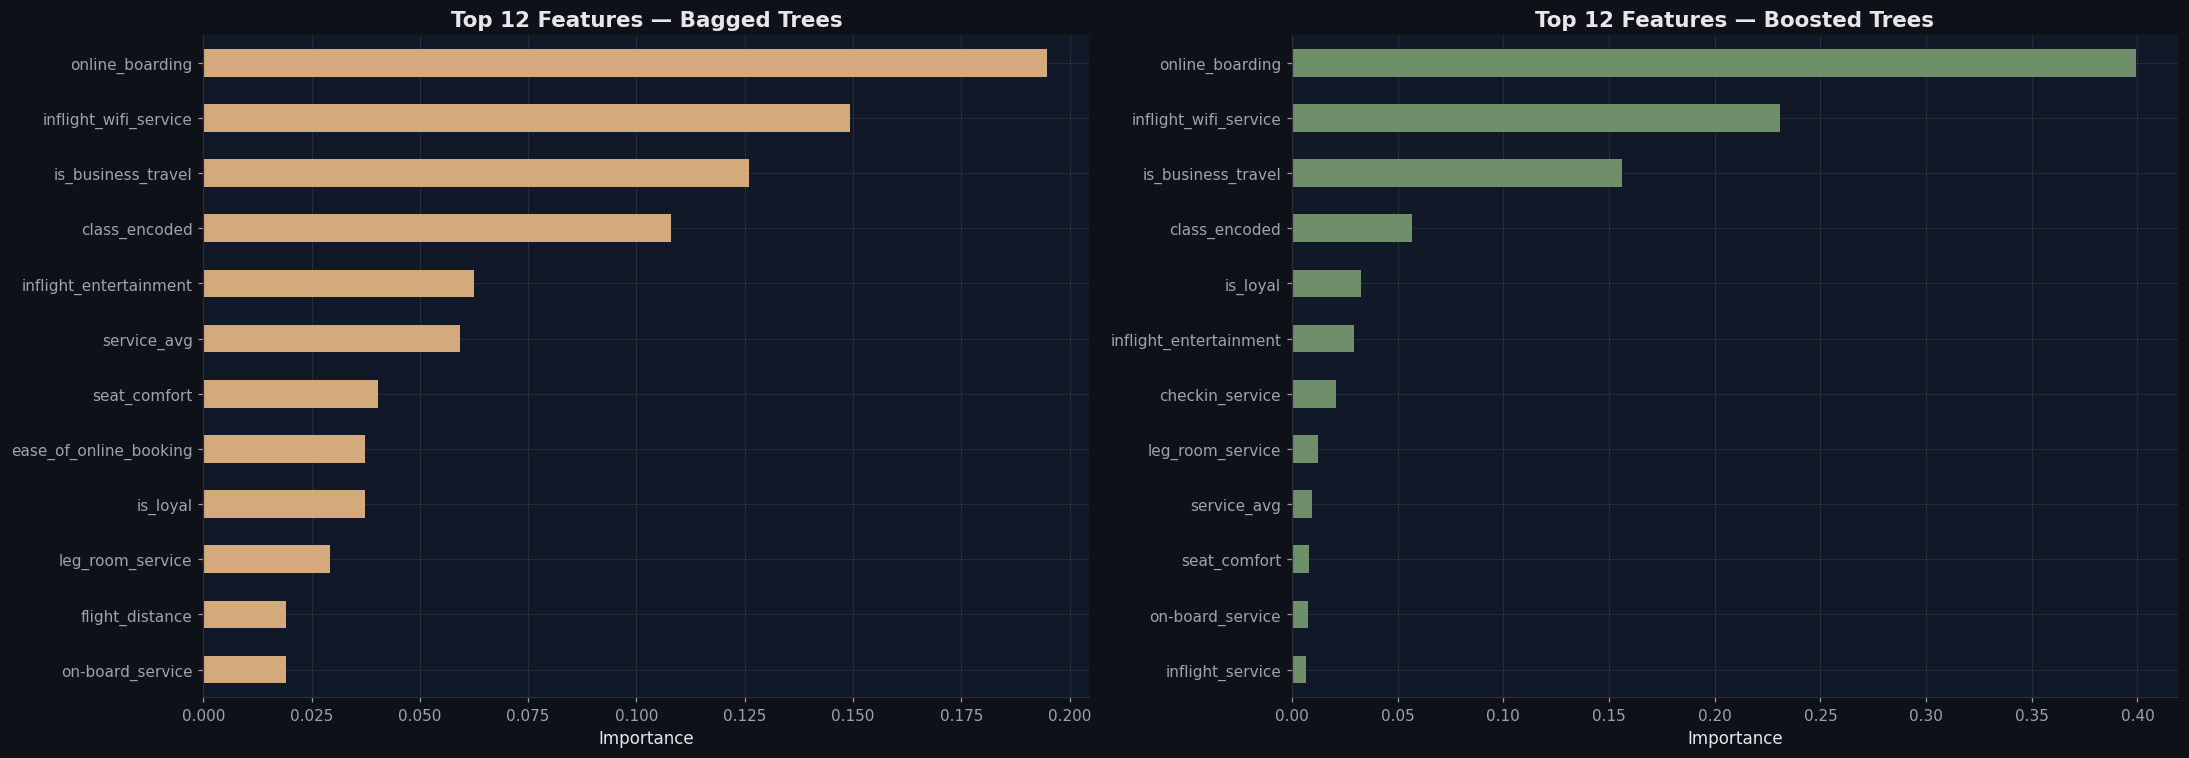

In [ ]:
#@title ▶️ SECTION 10 – FEATURE IMPORTANCE (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════
display(section_header("10", "Feature Importance",
    "Which features drive satisfaction? (sklearn built-in — no external library)"))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, model, name, color in zip(
    axes, [rf_model, gb_model],
    ['Bagged Trees', 'Boosted Trees'], [PRIMARY, ACCENT] # Changed SAND to PRIMARY, GREEN to ACCENT
):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    top12 = imp.nlargest(12).sort_values()
    top12.plot(kind='barh', ax=ax, color=color, edgecolor='none')
    ax.set_title(f'Top 12 Features — {name}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking
imp_gb = pd.Series(gb_model.feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)
display(insight_box(
    f"<strong>Top 3 features (Boosted Trees):</strong> "
    f"1. {imp_gb.index[0]} ({imp_gb.values[0]:.4f}) · "
    f"2. {imp_gb.index[1]} ({imp_gb.values[1]:.4f}) · "
    f"3. {imp_gb.index[2]} ({imp_gb.values[2]:.4f})",
    PRIMARY
))

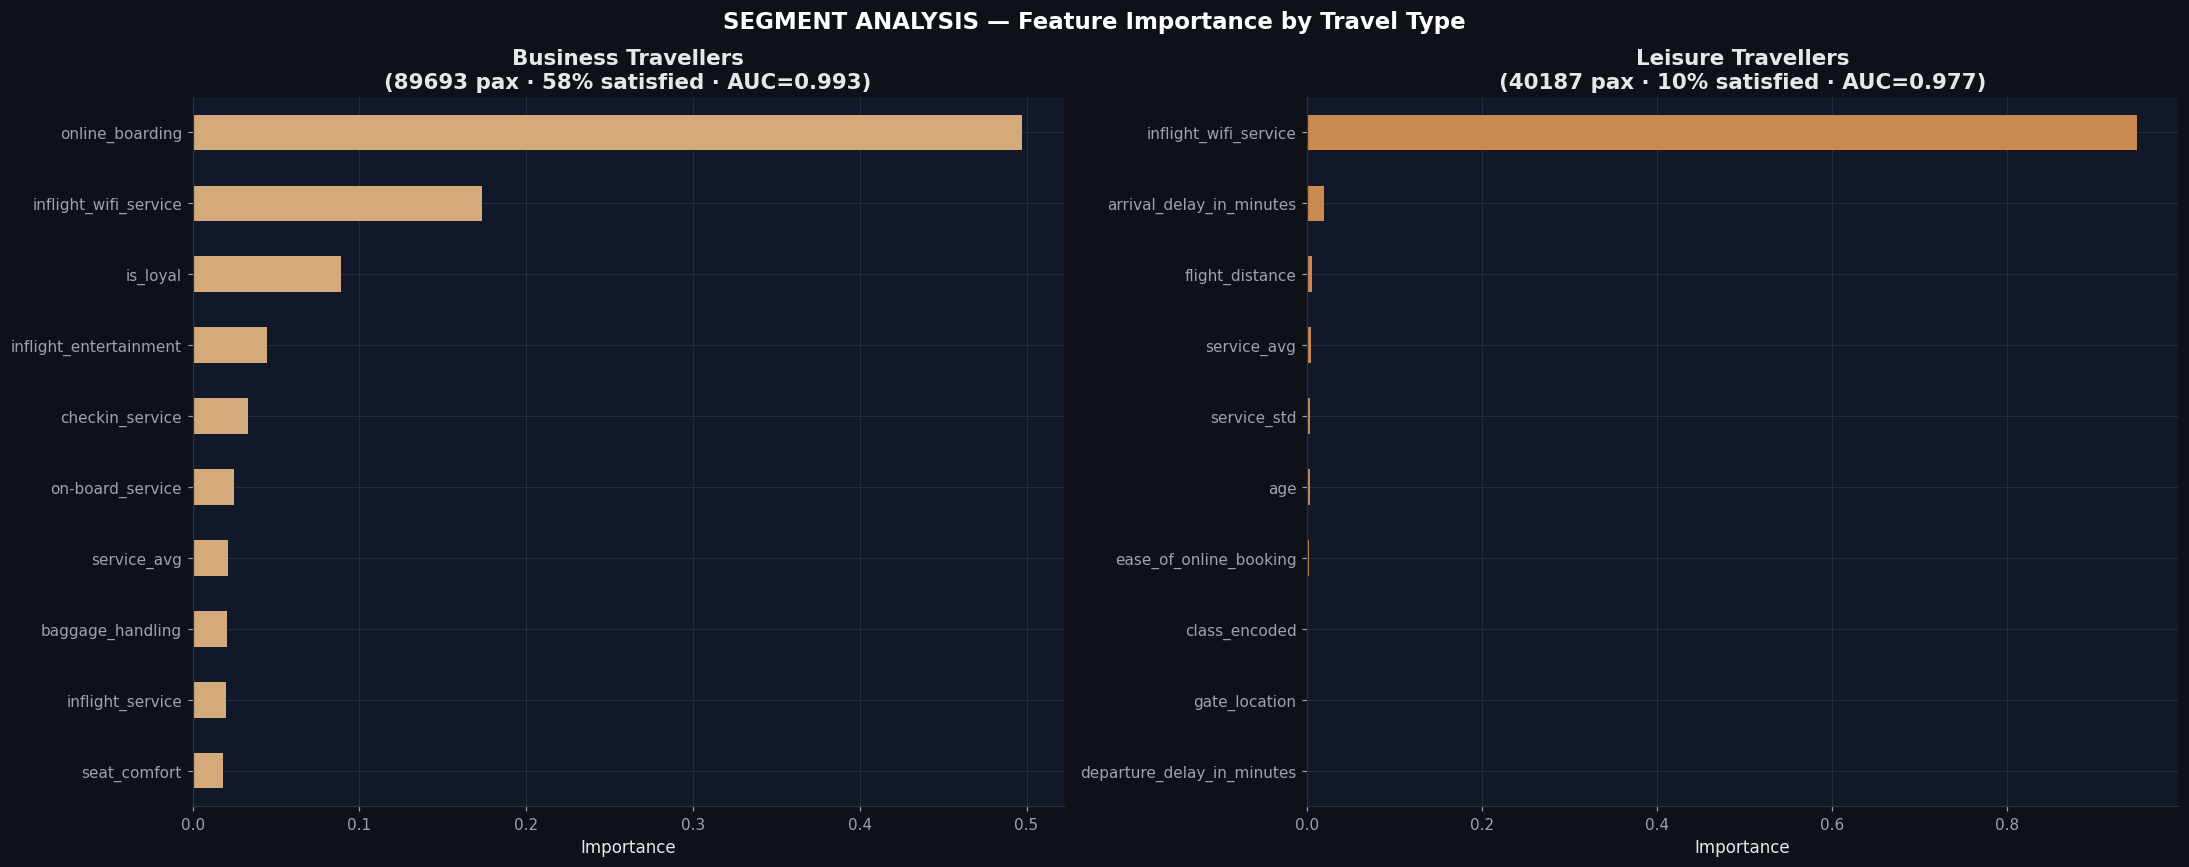

In [ ]:
#@title ▶️ SECTION 11 – SEGMENT ANALYSIS – THE DIFFERENTIATOR (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("11", "Segment Analysis — The Differentiator",
    "Training separate models per segment reveals fundamentally different satisfaction drivers"))

seg_results = {}
for seg_label, seg_val in [('Business Travellers', 1), ('Leisure Travellers', 0)]:
    mask  = df_model['is_business_travel'] == seg_val
    X_seg = df_model.loc[mask, FEATURE_COLS]
    y_seg = df_model.loc[mask, 'target']

    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42, stratify=y_seg)

    m = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                   max_depth=4, random_state=42)
    m.fit(X_tr_s, y_tr_s)
    yp_s    = m.predict(X_te_s)
    yprob_s = m.predict_proba(X_te_s)[:, 1]

    seg_results[seg_label] = {
        'model'   : m,
        'auc'     : roc_auc_score(y_te_s, yprob_s),
        'kappa'   : cohen_kappa_score(y_te_s, yp_s),
        'sat_rate': y_seg.mean() * 100,
        'imp'     : pd.Series(m.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False),
        'n'       : len(X_seg),
    }

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('SEGMENT ANALYSIS — Feature Importance by Travel Type',
             fontsize=15, fontweight='bold', color='white')

for ax, (seg, data), color in zip(axes, seg_results.items(), [PRIMARY, HIGHLIGHT]):
    top10 = data['imp'].head(10).sort_values()
    top10.plot(kind='barh', ax=ax, color=color, edgecolor='none')
    ax.set_title(f'{seg}\n({data["n"]} pax · {data["sat_rate"]:.0f}% satisfied '
                 f'· AUC={data["auc"]:.3f})')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Key finding
biz5  = list(seg_results['Business Travellers']['imp'].head(5).index)
leis5 = list(seg_results['Leisure Travellers']['imp'].head(5).index)

display(HTML(f'''
<div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin:14px 0;">
  <div style="background:rgba(212,170,125,0.08);border:1px solid rgba(212,170,125,0.25);
              border-radius:12px;padding:16px;">
    <div style="font-size:12px;font-weight:700;color:{PRIMARY};text-transform:uppercase;">
      Business Travellers — Top 5</div>
    <div style="font-size:13px;color:#ccd4de;margin-top:8px;line-height:2;">
      {"<br>".join(f"{i+1}. {f}" for i, f in enumerate(biz5))}
    </div>
  </div>
  <div style="background:rgba(243,156,18,0.05);border:1px solid rgba(243,156,18,0.2);
              border-radius:12px;padding:16px;">
    <div style="font-size:12px;font-weight:700;color:{HIGHLIGHT};text-transform:uppercase;">
      Leisure Travellers — Top 5</div>
    <div style="font-size:13px;color:#ccd4de;margin-top:8px;line-height:2;">
      {"<br>".join(f"{i+1}. {f}" for i, f in enumerate(leis5))}
    </div>
  </div>
</div>
'''))

display(insight_box(
    "<strong>Key finding:</strong> The satisfaction drivers differ significantly across segments. "
    "A uniform investment strategy misallocates capital. Airlines should differentiate "
    "service improvement priorities by travel type.",
    HIGHLIGHT, "★"
))

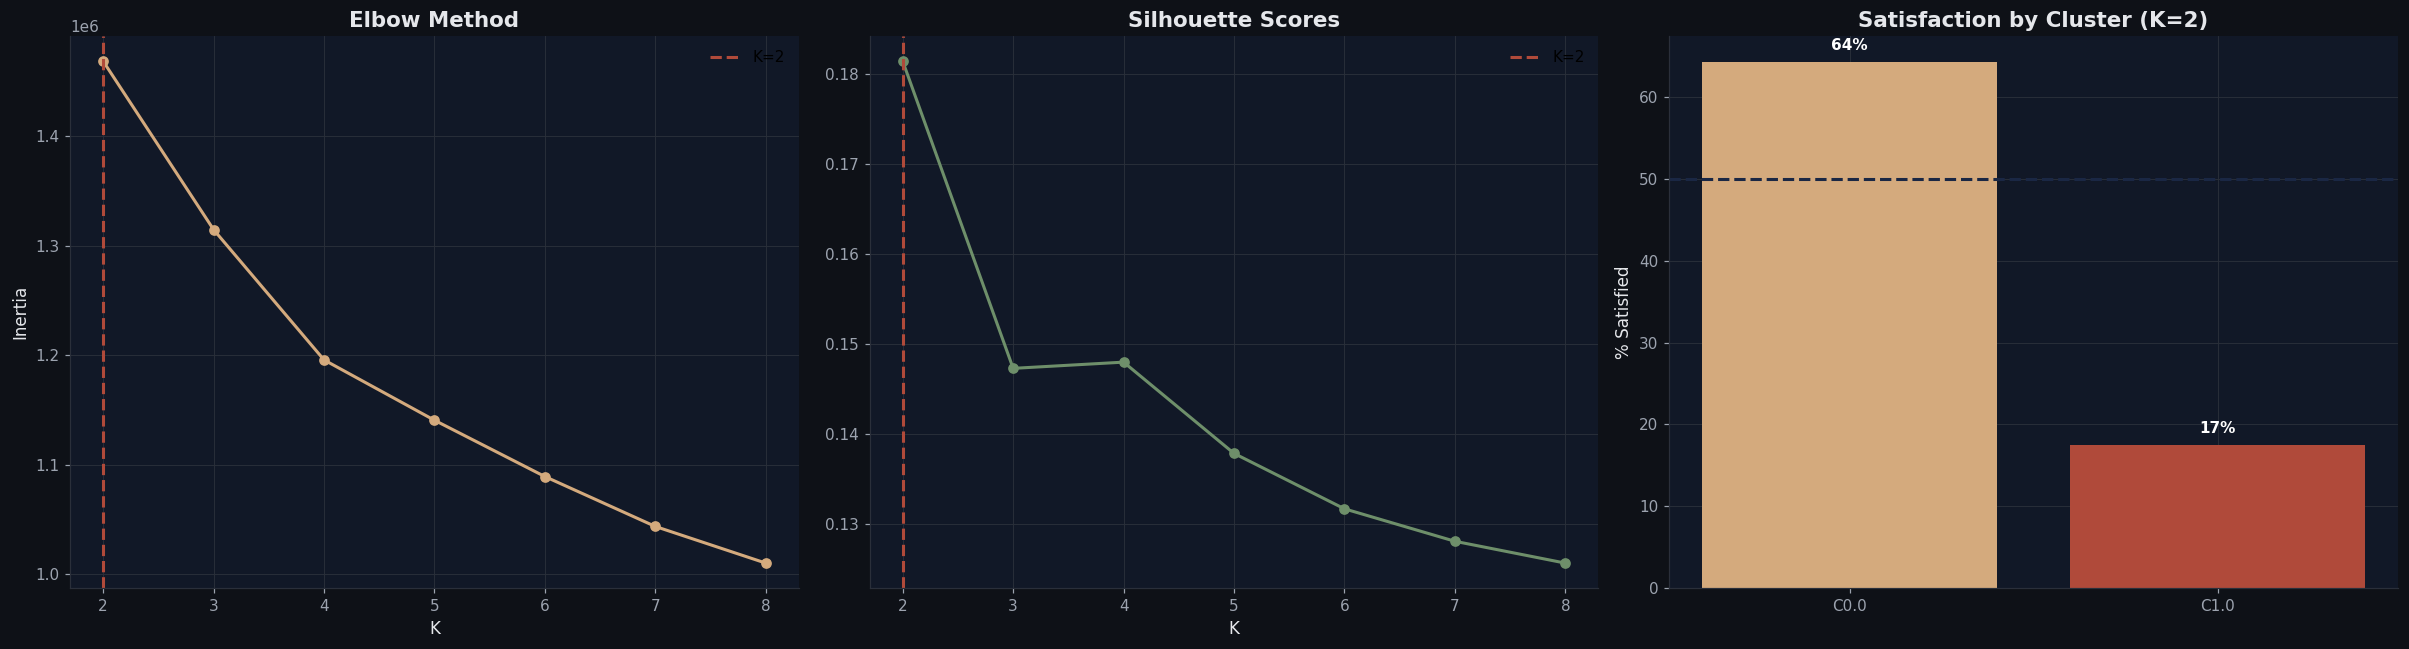

In [ ]:
#@title ▶️ SECTION 12 – UNSUPERVISED LEARNING – K-MEANS CLUSTERING (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("12", "Unsupervised Learning — K-Means Clustering",
    "Discovering natural passenger segments from service ratings"))

from sklearn.cluster import KMeans # Import KMeans
from sklearn.metrics import silhouette_score # Import silhouette_score

X_cl    = df_model[service_cols].dropna()
scaler_k = StandardScaler()
X_cl_sc  = scaler_k.fit_transform(X_cl)

inertias, sils = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl_sc)
    inertias.append(km.inertia_)
    idx_s = np.random.RandomState(42).choice(len(X_cl_sc),
                size=min(5000, len(X_cl_sc)), replace=False)
    sils.append(silhouette_score(X_cl_sc[idx_s], labels[idx_s]))

opt_k = range(2,9)[np.argmax(sils)]
km_final = KMeans(n_clusters=opt_k, random_state=42, n_init=10)
df_model.loc[X_cl.index, 'cluster'] = km_final.fit_predict(X_cl_sc)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].plot(range(2,9), inertias, marker='o', color=PRIMARY, linewidth=2)
axes[0].axvline(opt_k, color=SECONDARY, linestyle='--', label=f'K={opt_k}')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(range(2,9), sils, marker='o', color=ACCENT, linewidth=2)
axes[1].axvline(opt_k, color=SECONDARY, linestyle='--', label=f'K={opt_k}')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('K')
axes[1].legend()

sat_cl = df_model[df_model['cluster']>=0].groupby('cluster')['target'].mean()*100
colors_cl = [PRIMARY if v>50 else SECONDARY for v in sat_cl]
axes[2].bar([f'C{i}' for i in sat_cl.index], sat_cl.values,
            color=colors_cl, edgecolor='none')
axes[2].axhline(50, color='#1a2744', linestyle='--')
axes[2].set_title(f'Satisfaction by Cluster (K={opt_k})')
axes[2].set_ylabel('% Satisfied')
for i, v in enumerate(sat_cl.values):
    axes[2].text(i, v+1.5, f'{v:.0f}%', ha='center',
                fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('clustering.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#@title ▶️ SECTION 13 – RESULTS INTEERPRETATION & EXECUTIVE SUMMARY (click to expand/hide code)
# ══════════════════════════════════════════════════════════════════════

display(section_header("13", "Results Interpretation & Executive Summary",
    "What we found, what it means, and what we recommend"))

best_name = comp['AUC-ROC'].idxmax()
best_auc  = comp.loc[best_name, 'AUC-ROC']
best_kap  = comp.loc[best_name, 'Kappa']
best_mcc  = comp.loc[best_name, 'MCC']
best_acc  = comp.loc[best_name, 'Accuracy']

display(HTML(f'''
<div style="background:linear-gradient(135deg,rgba(212,170,125,0.10),rgba(0,194,203,0.02));
            border:1px solid rgba(212,170,125,0.25);border-radius:14px;
            padding:28px;margin:14px 0;">
  <div style="font-size:11px;font-weight:700;letter-spacing:0.12em;
              text-transform:uppercase;color:{PRIMARY};margin-bottom:14px;">
    Executive Summary
  </div>
  <div style="font-size:15px;color:#ccd4de;line-height:1.9;">
    We built a classification pipeline that processes <strong style="color:#fff;">25 features</strong>
    per passenger and predicts satisfaction with
    <strong style="color:{PRIMARY};">{best_acc:.1%} accuracy</strong> and an AUC-ROC of
    <strong style="color:{PRIMARY};">{best_auc:.4f}</strong>.
    Cohen's Kappa ({best_kap:.4f}) confirms this is a
    <strong style="color:{ACCENT};">good classifier</strong>
    (κ > 0.60).<br><br>

    The <strong style="color:#fff;">most important finding</strong> is not the accuracy —
    it's the segment analysis. Business travellers are driven by
    <strong style="color:{PRIMARY};'>digital efficiency</strong> (online boarding, wifi),
    while leisure travellers care about
    <strong style="color:{HIGHLIGHT};'>physical comfort</strong> (seat, entertainment, food).
    A uniform improvement strategy systematically misallocates capital.<br><br>

    <strong style="color:#fff;">The model is not the deliverable. The strategic insight is.</strong>
  </div>
</div>
'''))

# ── Limitations table ──────────────────────────────────────────────────
display(HTML(f'''
<div style="font-size:14px;font-weight:700;color:#ffffff;margin:20px 0 10px;">
  Limitations
</div>
<div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
  <div style="background:rgba(192,57,43,0.04);border-left:3px solid {SECONDARY};
              border-radius:0 8px 8px 0;padding:12px 16px;">
    <div style="font-size:12px;font-weight:700;color:{SECONDARY};">Snapshot data</div>
    <div style="font-size:12px;color:#8899aa;margin-top:4px;">
      No temporal dimension — cannot detect trends over time</div>
  </div>
  <div style="background:rgba(192,57,43,0.04);border-left:3px solid {SECONDARY};
              border-radius:0 8px 8px 0;padding:12px 16px;">
    <div style="font-size:12px;font-weight:700;color:{SECONDARY};">Self-reported ratings</div>
    <div style="font-size:12px;color:#8899aa;margin-top:4px;">
      Subjective — 4/5 means different things to different people</div>
  </div>
  <div style="background:rgba(192,57,43,0.04);border-left:3px solid {SECONDARY};
              border-radius:0 8px 8px 0;padding:12px 16px;">
    <div style="font-size:12px;font-weight:700;color:{SECONDARY};">No operational data</div>
    <div style="font-size:12px;color:#8899aa;margin-top:4px;">
      Crew, aircraft type, load factor absent from dataset</div>
  </div>
  <div style="background:rgba(192,57,43,0.04);border-left:3px solid {SECONDARY};
              border-radius:0 8px 8px 0;padding:12px 16px;">
    <div style="font-size:12px;font-weight:700;color:{SECONDARY};">Correlation ≠ Causation</div>
    <div style="font-size:12px;color:#8899aa;margin-top:4px;">
      Feature importance shows association, not causal effect </div>
  </div>
</div>
'''
))